# Fast convolution

So, the english is not very good, I will improve that

In [36]:
import sympy as sy
import numpy as np

from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [37]:
import fitz

from utils import plot_pdf, symmetrical_polynomial_factorization

In [38]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This example work for different vector sizes but the result not is interesting.

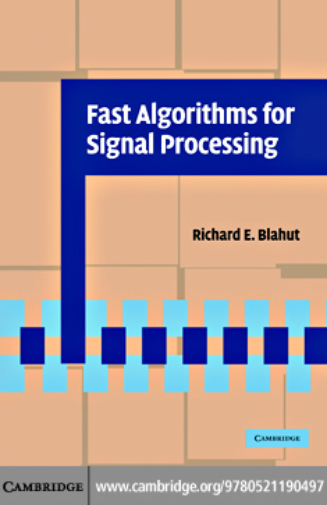

In [39]:
plot_pdf(doc[0], dpi=100)

## Polynomials

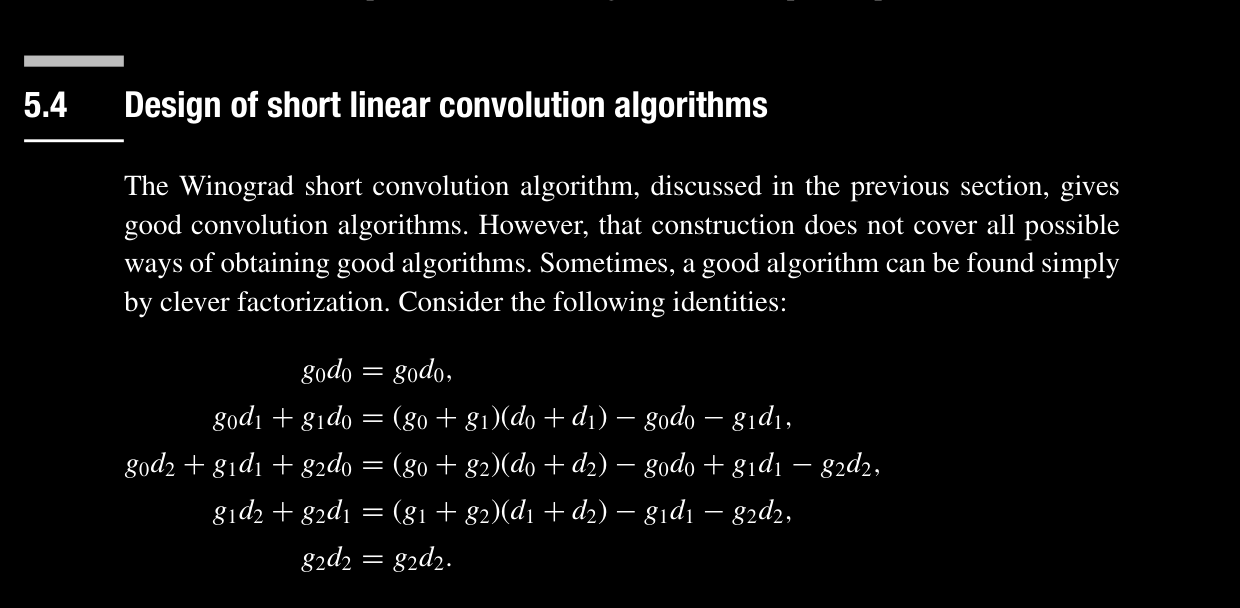

In [40]:
plot_pdf(doc[179], [.43, .75])

Size of vectors

In [41]:
d_num = 3
g_num = 3

Example of vectors for the convolution

In [42]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2, 3]


Polynomial degree

In [43]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 2


In [44]:
x = sy.symbols("x")
x

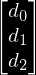

In [45]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

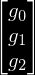

In [46]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

In [47]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

In [48]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

In [49]:
sx = gx*dx
sx

In [50]:
dg = sy.expand(sum(gi)*sum(di))
dg

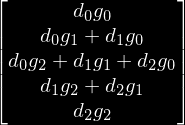

In [51]:
conv = sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))
conv

Resolvi isso com teoria de grupos

Os conjuntos $d$ e $g$ são os mesmos mas invertidos,
um se move no senti horário e outro no sentido inverso.

Então não preciso fazer operação em ambos mas somente em um e inverter o outro

Uma boa forma de demonstrar isso é usando dois triangulos, caso de polinômio de grau 2,
ou um vetor de 3 posições, se movendo mas o segundo triangulo se movendo no sentido
contrário

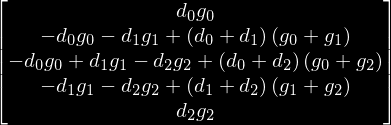

In [52]:
s0 = [symmetrical_polynomial_factorization(i, di, gi) for i in conv[1:-1]]
si = sy.Matrix([conv[0]] + s0 + [conv[-1]])
si

In [53]:
c_args = [i.args for i in si]
c_args

In [54]:
args = sorted(
    list(dict.fromkeys((-1)*ii if str(ii).startswith("-") else ii for i in c_args[1:-1] for ii in i)),
    key=lambda i: len(str(i))
)
args

In [55]:
# s_sym = sy.Matrix([[a if s.coeff(a, 1) != 0 else 0 for a in args] for s in si])
# s_sym

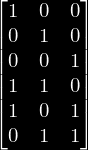

In [56]:
a_mtx = sy.Matrix([[1 if s.coeff(a, 1) != 0 else 0 for a in di] for s in sy.Matrix(args).expand()])
a_mtx

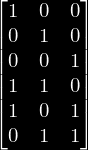

In [57]:
b_mtx = sy.Matrix([[1 if s.coeff(a, 1) != 0 else 0 for a in gi] for s in sy.Matrix(args).expand()])
b_mtx



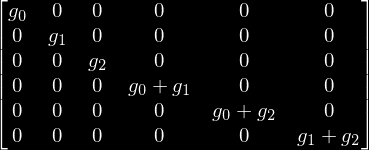

In [58]:
bg_mtx = sy.diag(*(b_mtx * gi))
bg_mtx

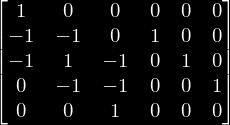

In [59]:
c_mtx = sy.Matrix([[s.coeff(a, 1) for a in args] for s in si])
c_mtx

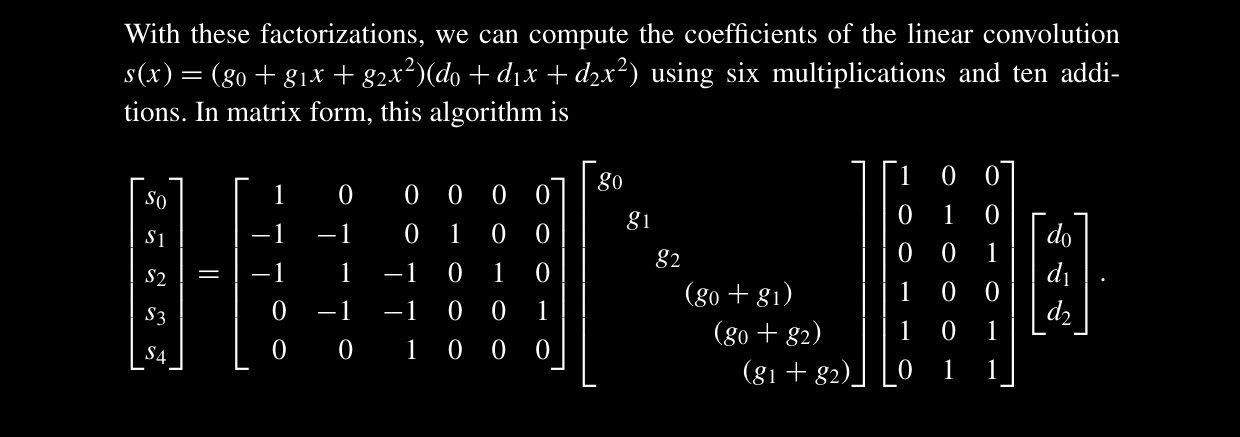

In [60]:
plot_pdf(doc[179], [.74, .97])


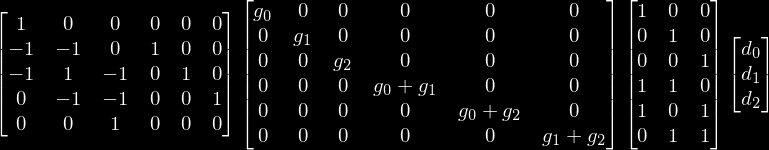

In [61]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
s

In [62]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

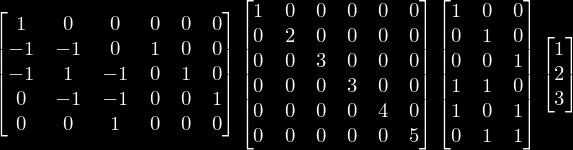

In [63]:
si = s.subs(subs)
si

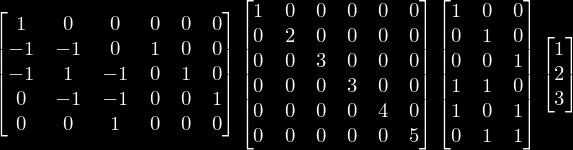

In [64]:
si = s.subs(subs)
si

In [65]:
sy.expand(sx)

Let's compare the output polynomial matrix from direct and winograd method

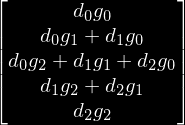

In [66]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

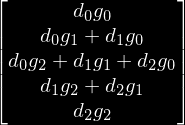

In [67]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

Comparing numerical outputs from direct and winograd method

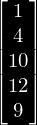

In [68]:
sy.Matrix(np.convolve(d_values, g_values))

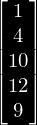

In [69]:
se.subs(subs)